### Interpretability - feature metrics

In [9]:
import os
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [10]:
coral_df = pd.read_csv("/work/hs325/World_Corals/Cleaned data CSVs/qc_data.csv")
met_df = pd.read_csv("/work/hs325/World_Corals/Cleaned data CSVs/merged_met_plot_df.csv")
coral_df['scleractinia'] = np.where(coral_df['host_order'] == 'Scleractinia', 1, 0)
met_df['refined_origin'] = met_df['refined_origin'].str.replace('Host', 'Coral')

X = coral_df[coral_df.columns.intersection(met_df['metabolite'])]
y = coral_df['scleractinia']

scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=88, stratify=y)


/tmp/ipykernel_2808640/989452537.py:1: DtypeWarning: Columns (8,17) have mixed types. Specify dtype option on import or set low_memory=False.
  coral_df = pd.read_csv("/work/hs325/World_Corals/Cleaned data CSVs/qc_data.csv")


### Feature selection

In [11]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import SelectPercentile
from sklearn.feature_selection import f_classif

## variance threshold doesn't remove enough testing Kbest and percentile

In [12]:
# Initialize a dictionary to store the dataframes
importance_storage = {}

# Define your datasets and models
datasets = {
    "KBest": SelectKBest(f_classif, k=16368),
}

models = {
    "RandomForest": RandomForestClassifier(random_state=88, n_jobs=-1),
    "XGBoost": XGBClassifier(random_state=88, use_label_encoder=False, eval_metric='logloss')
}

# Original feature names from the intersection
feature_names = coral_df.columns.intersection(met_df['metabolite']).values

for d_name, selector in datasets.items():
    selector.fit(X_train, y_train)
    X_train_sel = selector.transform(X_train)
    X_test_sel = selector.transform(X_test)
    
    mask = selector.get_support()
    selected_features = feature_names[mask]
    
    for m_name, model in models.items():
        model.fit(X_train_sel, y_train)
        y_pred = model.predict(X_test_sel)
        
        print(f"\n{m_name} on {d_name}")
        print(confusion_matrix(y_test, y_pred))
        
        feat_imp_df = pd.DataFrame({
            'Metabolite': selected_features,
            'Importance': model.feature_importances_
        }).sort_values(by='Importance', ascending=False).reset_index(drop=True)
        
        importance_storage[f"{m_name}_{d_name}"] = feat_imp_df

importance_storage

/hpc/group/schultzlab/hs325/miniconda3/envs/gsAI/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [  149   202   268   288   370   449   488   546   572   708   847   948
   950   966  1019  1098  1122  1127  1247  1334  1437  1470  1499  1696
  1839  1844  1916  2010  2097  2201  2271  2390  2445  2589  2674  2870
  3032  3169  3172  3446  3470  3641  3720  4253  4263  4297  4326  4382
  4416  4569  4788  4823  4909  5384  5764  5993  6044  6048  6138  6606
  6689  6793  6825  6932  7156  7305  7475  7497  7847  7906  8084  8182
  8193  8677  9274  9452  9472  9713  9768  9889 10107 10201 10384 10755
 10810 11793 12105 12316 12446 12620 12654 12688 13026 13113 13262 13279
 13626 14143 14157 14374 15230 15271 15352 15594 16337] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/hpc/group/schultzlab/hs325/miniconda3/envs/gsAI/lib/python3.12/site-packages/sklearn/feature_selection/_uni


RandomForest on KBest
[[28  0]
 [ 0 86]]


/hpc/group/schultzlab/hs325/miniconda3/envs/gsAI/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [00:06:51] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost on KBest
[[28  0]
 [ 0 86]]


{'RandomForest_KBest':                     Metabolite  Importance
 0      x40448_910_82144_16_435    0.015513
 1      x38490_972_80122_15_591    0.014619
 2      x39737_662_71722_16_103    0.013628
 3      x33780_862_69116_14_061    0.013105
 4        x8119_754_52307_4_568    0.012826
 ...                        ...         ...
 16363  x15343_1353_92371_7_455    0.000000
 16364  x28584_692_42808_12_884    0.000000
 16365    x18000_810_6019_8_543    0.000000
 16366  x34190_951_48365_14_182    0.000000
 16367  x26796_826_65978_12_468    0.000000
 
 [16368 rows x 2 columns],
 'XGBoost_KBest':                      Metabolite  Importance
 0         x1014_394_26002_1_302    0.293905
 1       x39975_976_83346_16_206    0.265096
 2       x40448_910_82144_16_435    0.112835
 3       x36108_538_59233_14_715    0.095076
 4         x1875_530_28797_1_954    0.045707
 ...                         ...         ...
 16363     x2937_414_35772_2_808    0.000000
 16364  x40915_1034_90818_16_764    0.000000

### Perm importance with multicollinear features

In [13]:
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr
from collections import defaultdict

In [14]:
feature_names = coral_df.columns.intersection(met_df['metabolite']).values

## Get top 500 metabolites instead from select K best
X_df = pd.DataFrame(
    X,
    columns=coral_df.columns.intersection(met_df['metabolite'])
)

# Split with DataFrames 
X_train, X_test, y_train, y_test = train_test_split(
    X_df, y, test_size=0.2, random_state=88, stratify=y
)

# Run SelectKBest on training data
k = min(500, X_train.shape[1])  
selector = SelectKBest(score_func=f_classif, k=k)
selector.fit(X_train, y_train)

top_mets = X_train.columns[selector.get_support()].values


/hpc/group/schultzlab/hs325/miniconda3/envs/gsAI/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [  149   202   268   288   370   449   488   546   572   708   847   948
   950   966  1019  1098  1122  1127  1247  1334  1437  1470  1499  1696
  1839  1844  1916  2010  2097  2201  2271  2390  2445  2589  2674  2870
  3032  3169  3172  3446  3470  3641  3720  4253  4263  4297  4326  4382
  4416  4569  4788  4823  4909  5384  5764  5993  6044  6048  6138  6606
  6689  6793  6825  6932  7156  7305  7475  7497  7847  7906  8084  8182
  8193  8677  9274  9452  9472  9713  9768  9889 10107 10201 10384 10755
 10810 11793 12105 12316 12446 12620 12654 12688 13026 13113 13262 13279
 13626 14143 14157 14374 15230 15271 15352 15594 16337] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/hpc/group/schultzlab/hs325/miniconda3/envs/gsAI/lib/python3.12/site-packages/sklearn/feature_selection/_uni

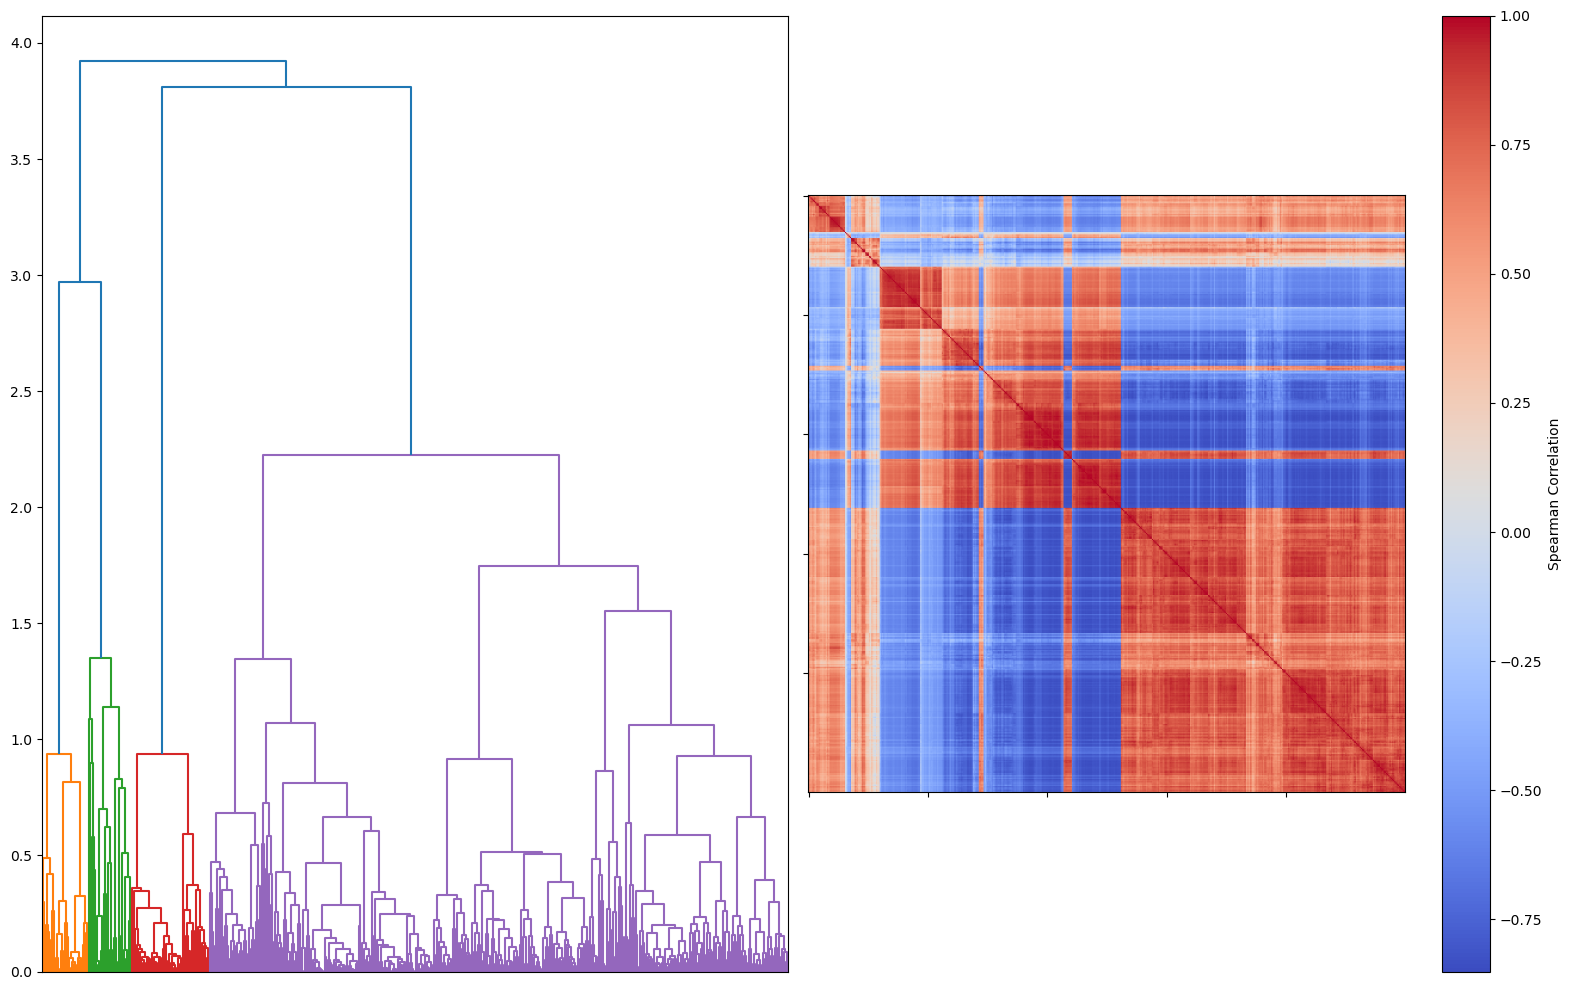

In [15]:
# top_mets = importance_storage["RandomForest_KBest"].head(500)['Metabolite'].values
# top_mets = importance_storage["XGBoost_KBest"].head(500)['Metabolite'].values
top_mets = X_train.columns[selector.get_support()].values

X_df = pd.DataFrame(X, columns=coral_df.columns.intersection(met_df['metabolite']))
X_subset = X_df[top_mets]

corr = spearmanr(X_subset).correlation
corr = (corr + corr.T) / 2
np.fill_diagonal(corr, 1)

distance_matrix = 1 - np.abs(corr)
dist_linkage = hierarchy.ward(squareform(distance_matrix))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))

dendro = hierarchy.dendrogram(
    dist_linkage, labels=top_mets.tolist(), ax=ax1, leaf_rotation=90
)
ax1.set_xticklabels([])

im = ax2.imshow(corr[dendro["leaves"], :][:, dendro["leaves"]], cmap='coolwarm')
ax2.set_xticklabels([])
ax2.set_yticklabels([])

fig.colorbar(im, ax=ax2, label='Spearman Correlation')
fig.tight_layout()
plt.savefig('/work/hs325/World_Corals/misc/figs/perm_importance_heatmap_AllKBest.jpg')

plt.show()

In [16]:
from collections import defaultdict
from scipy.cluster import hierarchy
from sklearn.ensemble import RandomForestClassifier
import numpy as np

cluster_ids = hierarchy.fcluster(dist_linkage, 1, criterion="distance")
n_features = len(cluster_ids)
print("Number of features in clustering:", n_features)

cluster_id_to_feature_ids = defaultdict(list)
for idx, cluster_id in enumerate(cluster_ids):
    cluster_id_to_feature_ids[cluster_id].append(idx)

selected_features_indices = [v[0] for v in cluster_id_to_feature_ids.values()]

# defensive: make indices unique and sorted
selected_features_indices = sorted(set(selected_features_indices))
selected_features_names = feature_names[selected_features_indices]
print(f"Reduced feature set from {len(feature_names)} to {len(selected_features_names)} clusters.")

def select_columns(X, indices):
    if hasattr(X, "iloc"):   # pandas DataFrame
        return X.iloc[:, indices].values
    else:                    # numpy array
        return X[:, indices]

X_train_sel = select_columns(X_train, selected_features_indices)
X_test_sel  = select_columns(X_test,  selected_features_indices)

print("X_train_sel shape:", X_train_sel.shape)
print("X_test_sel  shape:", X_test_sel.shape)

clf_sel = XGBClassifier(random_state=88, n_jobs=-1)
clf_sel.fit(X_train_sel, y_train)

accuracy = clf_sel.score(X_test_sel, y_test)
print(f"Baseline accuracy on test data with redundant features removed: {accuracy:.2f}")

# print selected feature names
print("Selected feature names after clustering:")
for name in selected_features_names:
    print(name)


Number of features in clustering: 500
Reduced feature set from 16368 to 13 clusters.
X_train_sel shape: (454, 13)
X_test_sel  shape: (114, 13)
Baseline accuracy on test data with redundant features removed: 0.94
Selected feature names after clustering:
x19344_800_60417_9_097
x22863_768_59077_10_971
x3156_482_36064_2_937
x19279_643_51751_9_054
x6124_510_39212_3_959
x23789_794_60652_11_52
x24253_770_60636_11_681
x28291_824_65392_12_805
x26753_788_61732_12_415
x23921_520_50907_11_562
x2650_676_42073_2_596
x1683_391_26322_1_789
x5181_648_22186_3_686
